In [156]:
import warnings
warnings.filterwarnings('ignore')

In [157]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from flonacomldft.utils.io_utils import (
    load_pickle_file,
    get_path
)

from flonacomldft.internal_coordinates import Coordinates_mapping
from flonacomldft.utils.diagnostics import R_hat

from flonacomldft.utils.plots import (
    set_plot_sequential_data,
    plot_energy_surface,
    plot_energy_histogram,
)

from numpy.lib.stride_tricks import sliding_window_view

import matplotlib.pylab as pylab

size=16
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

In [158]:
# paths
DFT_DATA_PATH = get_path() + '/andersen/'
DFT_SIMS_PATH = '/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/'

## 1. MCMC with mixture of isomers

In [159]:
# simulation files
mcmc_paths = ['5-multimodal/results_multimodal_sampling_mixture_29096190/mixture_mcmc_dic_29096190.pkl',
             '6-multimodal-mlp/results_multimodal_sampling_mixture_29134160/mixture_mcmc_dic_29134160.pkl',
             '6-multimodal-mlp/results_multimodal_sampling_mixture_29134161/mixture_mcmc_dic_29134161.pkl',
             #'6-multimodal-mlp/results_multimodal_sampling_mixture_29681760/mixture_mcmc_dic_29681760.pkl', #alpha 0.1
             #'6-multimodal-mlp/results_multimodal_sampling_mixture_29681651/mixture_mcmc_dic_29681651.pkl' #alpha 0.5
             ]

# load mcmc results
keys = ['DFT-DFT', 'DFT-MLP', 'MLP-MLP']
color_keys = dict(zip(keys, ['blue', 'orange', 'red']))
mcmcs = {key: load_pickle_file(mcmc_path, DFT_SIMS_PATH) for mcmc_path, key in zip(mcmc_paths, keys)}

### 1.a Acceptance ratio

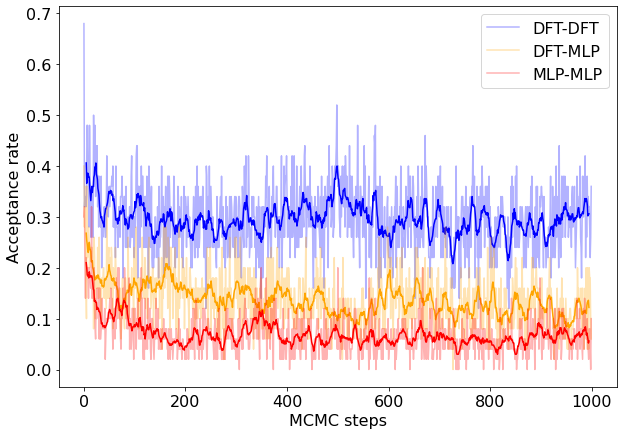

In [160]:
accs = {key: mcmcs[key]['accs'].mean(dim=1).detach() for key in mcmcs.keys()}

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

for key in accs.keys():

    set_plot_sequential_data(accs[key], ax=ax, label=key, color=color_keys[key])
    ax.set_xlabel('MCMC steps')
    ax.set_ylabel('Acceptance rate')

ax.legend()

### 1.b Collective variables

In [6]:
def get_collective_variable(simulation, etype='dft'):

    coord_mapping = Coordinates_mapping(etype=etype)

    xs = simulation['xs']
    xs_flatten = xs.reshape(-1, 12)

    isomers_mask = simulation['isomers'].reshape(-1, 1)

    xs_is0 = []
    xs_is1 = []

    for isomer, x in zip(isomers_mask, xs_flatten):
        if isomer==0:
            xs_is0.append(x)
        elif isomer==1:
            xs_is1.append(x)
        else:
            raise Warning('Not found!')

    xs_is0 = torch.stack(xs_is0) 
    xs_is1 = torch.stack(xs_is1)

    cvs_is0 = coord_mapping.get_collective_variables_from_real_centered(xs_is0, isomer=0)
    cvs_is1 = coord_mapping.get_collective_variables_from_real_centered(xs_is1, isomer=1)

    return cvs_is0, cvs_is1


In [7]:
cvs = {key: get_collective_variable(mcmcs[key]) for key in mcmcs.keys()}

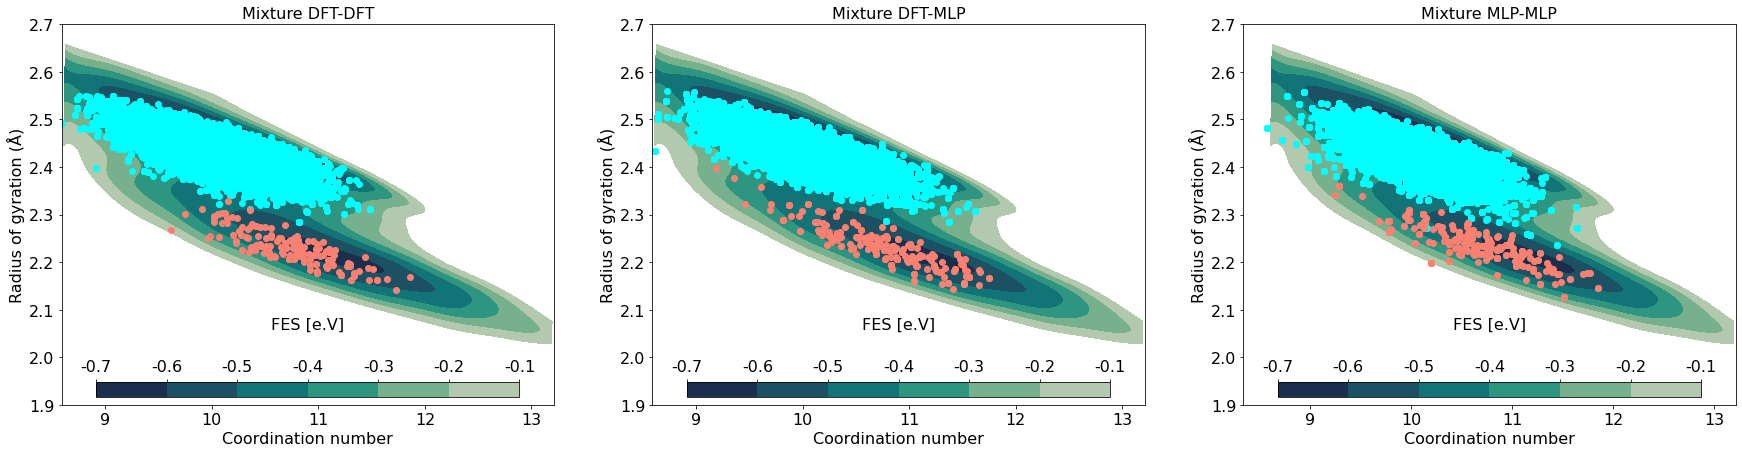

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(30, 7))

axs = axs.ravel()

for ax, key in zip(axs, cvs.keys()):

    plot_energy_surface(fig=fig, ax=ax)

    ax.scatter(cvs[key][0][:, 0], cvs[key][0][:, 1], c='cyan')
    ax.scatter(cvs[key][1][:, 0], cvs[key][1][:, 1], c='salmon')
    ax.set_title('Mixture {:s}'.format(key))


### 1.c Jumps between isomers

In [161]:
def plot_jums_along_chains(ax, isomers, size=6):

    isomers = isomers.T

    for i in range(isomers.shape[0]):

        jumps, counts = isomers[i].unique_consecutive(return_counts=True)

        colors_array = []
        
        for j in range(jumps.shape[0]):
            if jumps[j]==0:
                colors_array.append('cyan')
            else:
                colors_array.append('salmon')
        
        ax.plot(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), 'k--', alpha=0.4)
        ax.scatter(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), s=counts*size, color=colors_array)
    
    ax.set_xlabel('Chains')
    ax.set_ylabel('Jumps')

In [162]:
isomers = {key: mcmcs[key]['isomers'] for key in mcmcs.keys()}

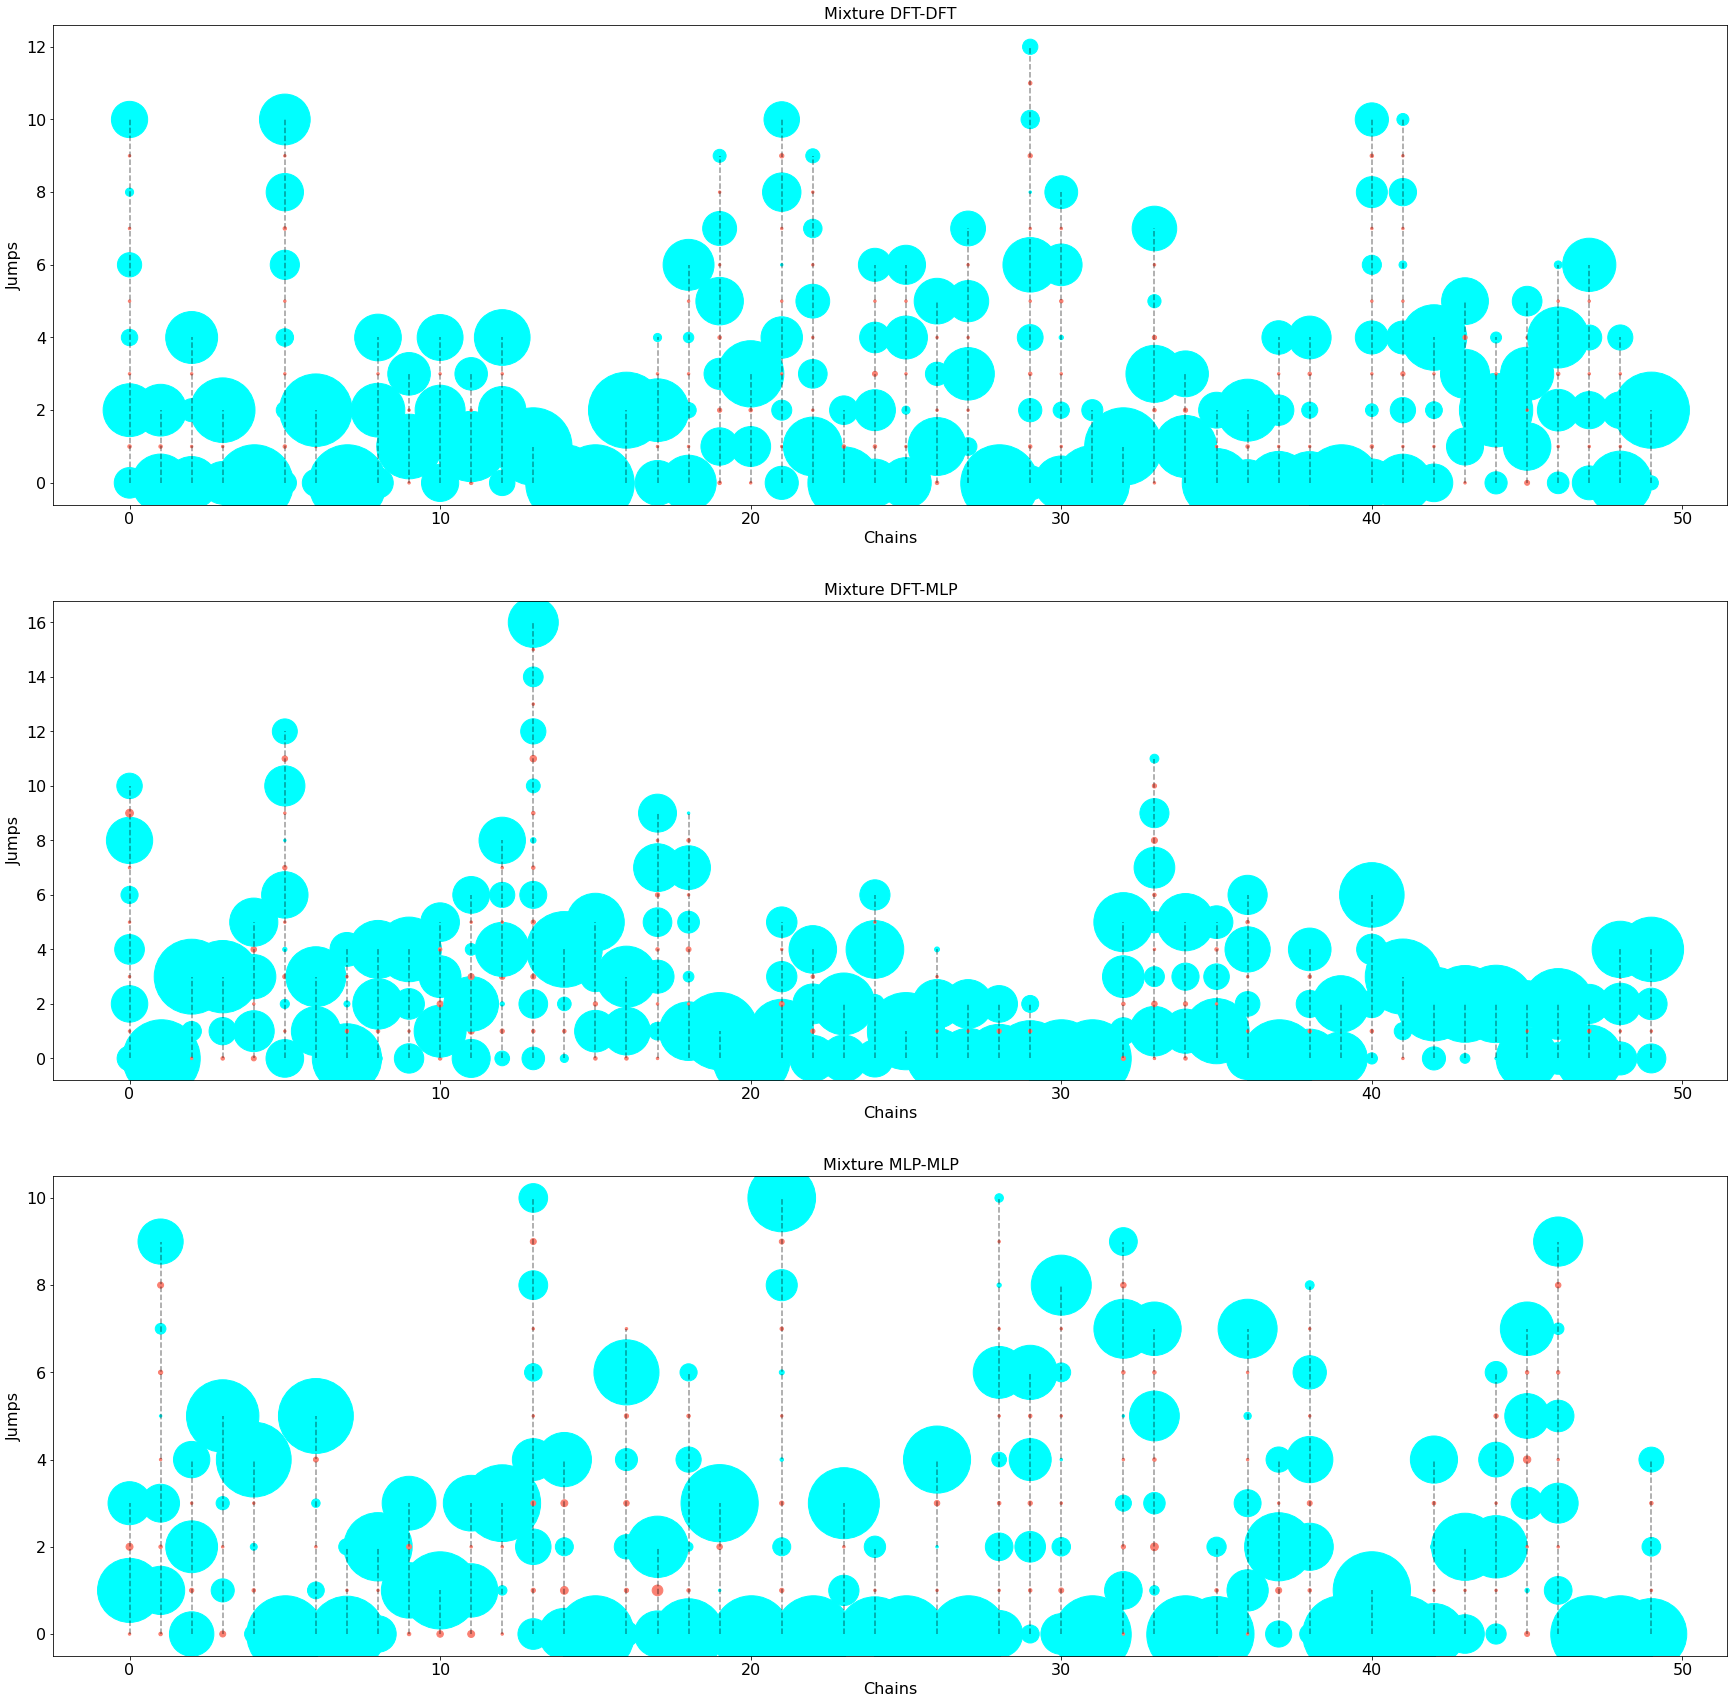

In [163]:
fig, axs = plt.subplots(3, 1, figsize=(30, 30))

axs = axs.ravel()

for ax, key in zip(axs, isomers.keys()):
    plot_jums_along_chains(ax, isomers[key])

    ax.set_title('Mixture {:s}'.format(key))

In [164]:
def plot_jumps_along_steps(ax, isomers):

    ax.plot(isomers.detach().numpy(), '.-')
    ax.set_xlabel('MCMC steps')
    ax.set_ylabel('Isomer')

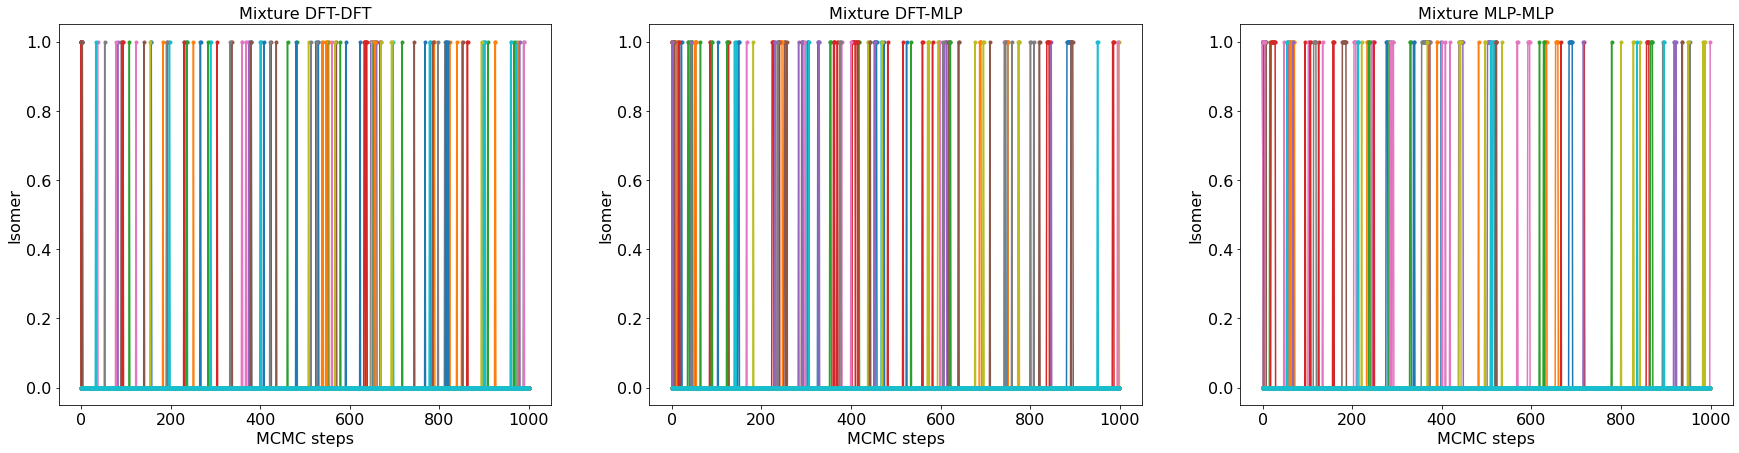

In [165]:
fig, axs = plt.subplots(1, 3, figsize=(30, 7))

axs = axs.ravel()

for ax, key in zip(axs, isomers.keys()):
    plot_jumps_along_steps(ax, isomers[key])

    ax.set_title('Mixture {:s}'.format(key))

### 1.d Rhat test

In [166]:
def get_zmat_from_real(xs, isomers, etype='dft'):

    xs = xs.clone().detach().numpy().transpose(1, 0, 2)
    isomers = isomers.clone().detach().numpy().transpose(1, 0)

    coord_mapping = Coordinates_mapping(etype=etype)

    zmat = torch.zeros(xs.shape)

    for i in range(xs.shape[1]):
        for j in range(xs.shape[0]):
            zmat[j, i] = coord_mapping.get_internal_from_real_centered(torch.tensor(xs[j, i]).reshape(1, -1), 
                                                                        isomer=isomers[j, i])[0]
    zmat = zmat.clone().detach().numpy()

    return zmat

In [167]:
def plot_rhat(ax, rhat):

    ax.plot(rhat[1], rhat[0], '-o',  label=rhat[2])
    ax.axhline(1, c='k', ls='--')
    ax.axhline(1.01, c='grey', ls='--')
    ax.set_xlabel('Iteration')
    ax.set_ylabel(r'$\hat{R}$')

In [168]:
xs = {key: mcmcs[key]["xs"].detach() for key in mcmcs.keys()}

In [169]:
zmats = {key: get_zmat_from_real(xs[key], isomers[key]) for key in xs.keys()}

rhat_s = {key: R_hat(zmats[key], n_split=10) for key in ['DFT-MLP', 'MLP-MLP']}
rhat_s['DFT-DFT'] = R_hat(zmats['DFT-DFT'], n_split=10)

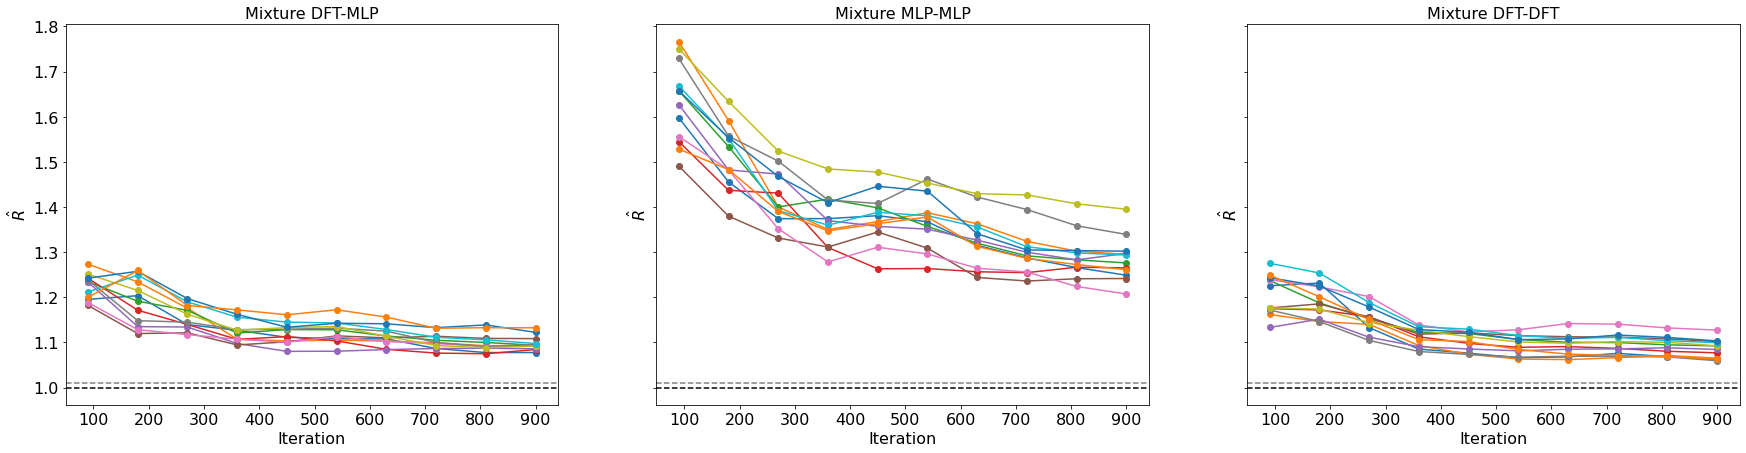

In [170]:
fig, axs = plt.subplots(1, 3, figsize=(30, 7), sharey=True)

axs = axs.ravel()

for ax, key in zip(axs, rhat_s.keys()):
    plot_rhat(ax, rhat_s[key])

    ax.set_title('Mixture {:s}'.format(key))

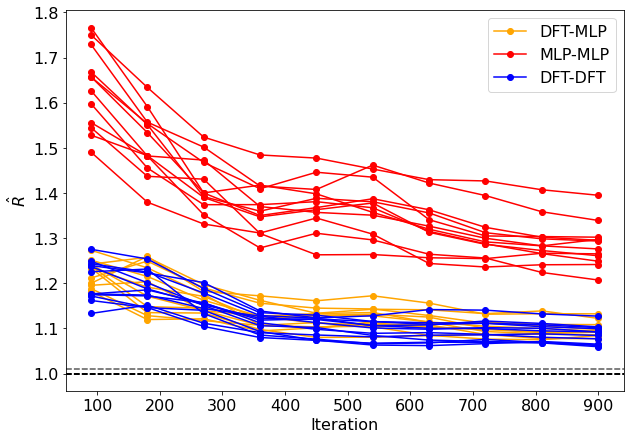

In [171]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
for key in rhat_s.keys():
    ax.plot(rhat_s[key][1], rhat_s[key][0], '-o',  label=key, color=color_keys[key])
    ax.axhline(1, c='k', ls='--')
    ax.axhline(1.01, c='grey', ls='--')
    ax.set_xlabel('Iteration')
    ax.set_ylabel(r'$\hat{R}$')

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))

    ax.legend(by_label.values(), by_label.keys())

### 1.e Energies

Text(0.5, 1.0, 'Energy histogram')

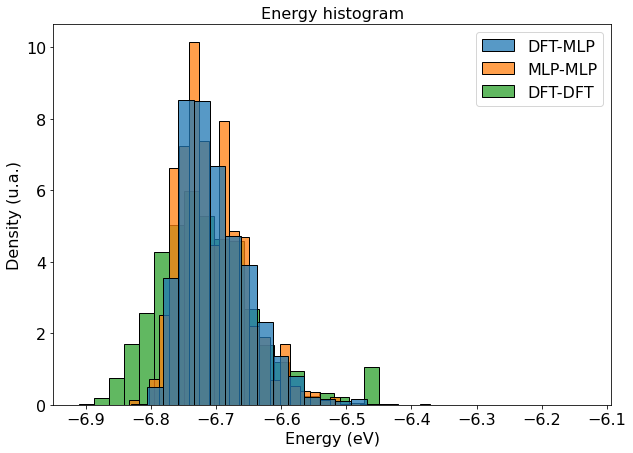

In [172]:
us = {key: mcmcs[key]['us'].flatten().detach() for key in mcmcs.keys()}

fig, axs = plt.subplots(1, 1, figsize=(10, 7))

plot_energy_histogram(us, ax=axs, bins=30, alpha=0.75, hue_order=['DFT-MLP', 'MLP-MLP', 'DFT-DFT'], common_bins=False, common_norm=False)
axs.set_title(f'Energy histogram')

In [177]:
mlps = {i: load_pickle_file('dict_mlp_model_is{:d}_adaptive.pkl'.format(i), get_path() + '/andersen/models') for i in [0, 1]}

In [183]:
upper = -6.75
selected_us = mcmcs['DFT-DFT']['us']<upper
indices = torch.nonzero(selected_us)

In [184]:
target_us = torch.stack([mcmcs['DFT-DFT']['us'][i[0]][i[1]] for i in indices])
selected_xs = torch.stack([mcmcs['DFT-DFT']['xs'][i[0]][i[1]] for i in indices])
selected_isomers = torch.stack([mcmcs['DFT-DFT']['isomers'][i[0]][i[1]] for i in indices])

In [185]:
masks = [~selected_isomers.bool(), selected_isomers.bool()]
sel_xs = {i: selected_xs[mask] for i, mask in enumerate(masks)}

sel_us_target = {i: target_us[mask] for i, mask in enumerate(masks)}

In [186]:
us_pred = {i: mlps[i]['models'][-1](sel_xs[i]) for i in range(2)}

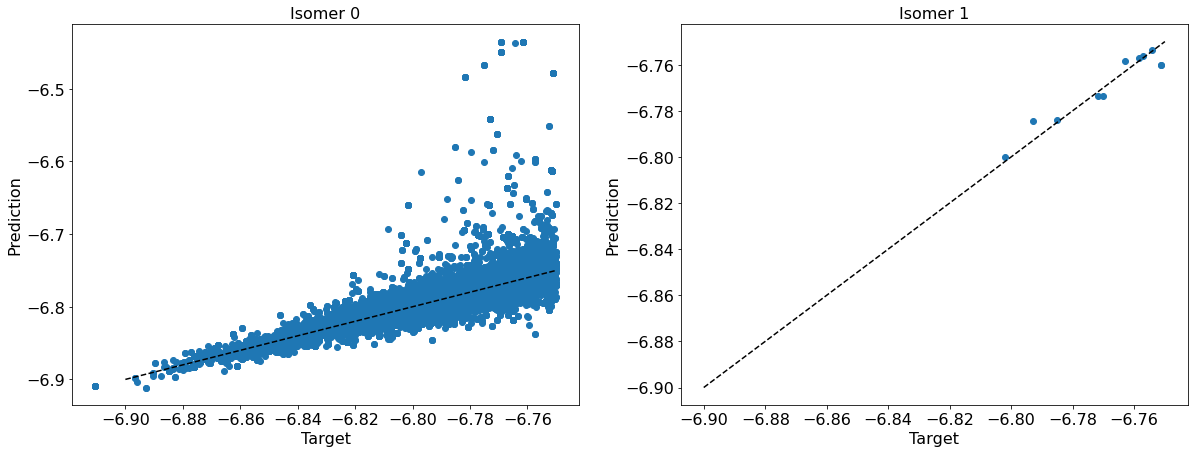

In [187]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))
axs = axs.ravel()

for i, ax in enumerate(axs):
    ax.plot(sel_us_target[i].flatten().detach(), us_pred[i].flatten().detach(), 'o')
    ax.set_xlabel('Target')
    ax.set_ylabel('Prediction')
    ax.plot([-6.9, upper], [-6.9, upper], 'k--')
    ax.set_title(f'Isomer {i}')

In [188]:
us = {key: mcmcs[key]['us'] for key in mcmcs.keys()}

nrows = 25

us_splitted = {key: torch.stack([us[key][i*nrows: (i+1)*nrows, :].flatten().detach() for i in range(4)])
                    for key in mcmcs.keys()}

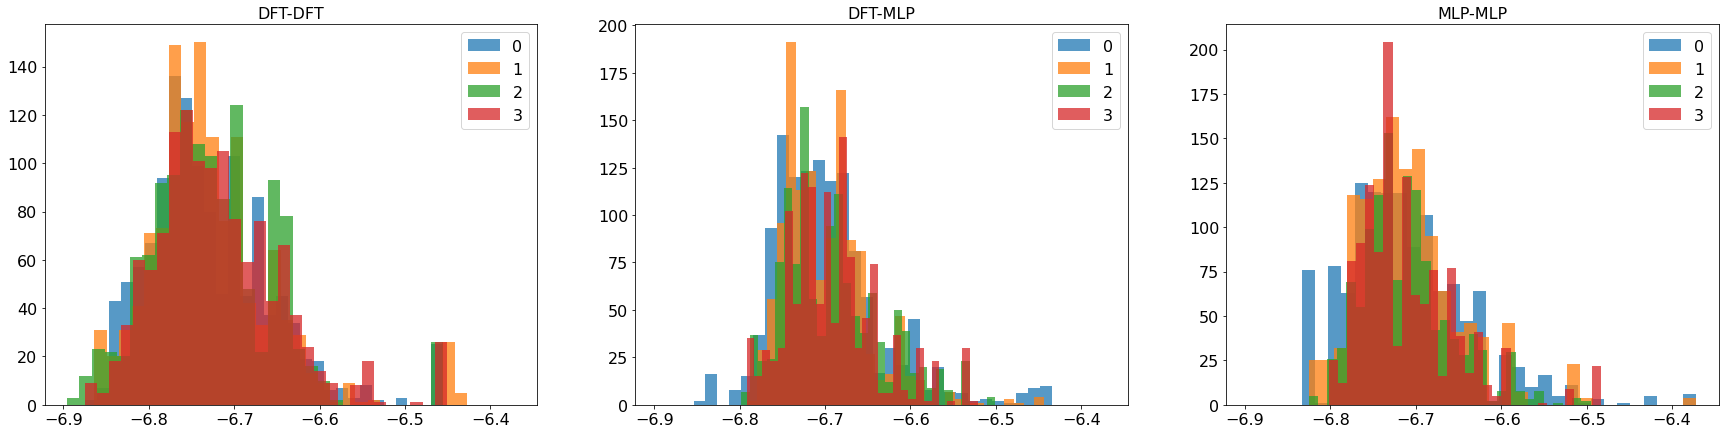

In [189]:
fig, axs = plt.subplots(1, 3, figsize=(30, 7), sharex=True)
axs = axs.ravel()

for ax, key in zip(axs, us_splitted.keys()):
    for i, u in enumerate(us_splitted[key]):
        ax.hist(u, bins=30, label=i, alpha=0.75)
    ax.legend()
    ax.set_title(key)

### 1.f Populations

In [190]:
def compute_population_windows(isomers, window_size=50):

    isomers_window = sliding_window_view(isomers.detach().numpy(), window_shape=window_size, axis=0)
    population_window = np.array([isomer_window.mean() for isomer_window in isomers_window])

    return population_window

In [191]:
populations_is1 = {key: compute_population_windows(isomers[key], 100) for key in isomers.keys()}

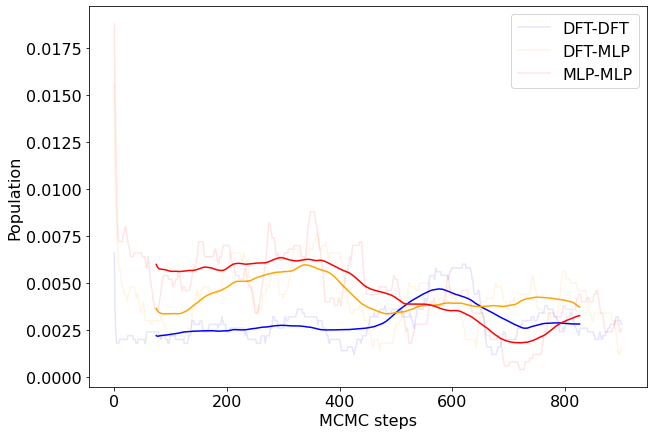

In [199]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

for key in populations_is1.keys():
    set_plot_sequential_data(populations_is1[key], avg=True, ax=ax, window_size=150, label=key, color=color_keys[key], alpha=0.1)

ax.set_xlabel('MCMC steps')
ax.set_ylabel('Population')
ax.legend()

In [201]:
for key in populations_is1.keys():
    print(f'Population {key}: {populations_is1[key][500:].mean()}')

Population DFT-DFT: 0.0033905236050486565
Population DFT-MLP: 0.0039107236079871655
Population MLP-MLP: 0.0029501249082386494


### 1.g Time simulations

In [202]:
time_mcmc = {}
time_mcmc_window = {}

for key in mcmcs.keys():
    time_list = mcmcs[key]['time_mcmc']
    time_init = time_list[0]
    final_time = [(t - time_init)/3600 for t in time_list]
    time_mcmc[key] = final_time
    time_mcmc_window[key] = sliding_window_view(final_time, 100, axis=0).mean(axis=1)


In [203]:
time_mcmc_window['DFT-DFT'].shape, populations_is1['DFT-DFT'].shape

((901,), (901,))

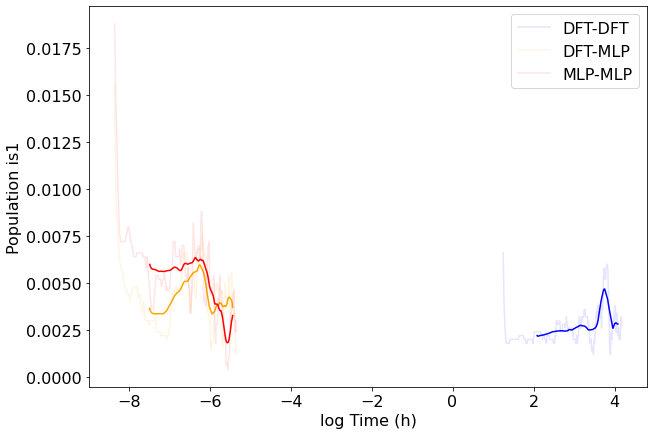

In [212]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

for key in keys:
    set_plot_sequential_data(y=populations_is1[key], x=np.log(time_mcmc_window[key]), avg=True, window_size=150, ax=ax, label=key, color=color_keys[key], alpha=0.1)
    ax.legend()
    ax.set_xlabel('log Time (h)')
    ax.set_ylabel('Population is1')

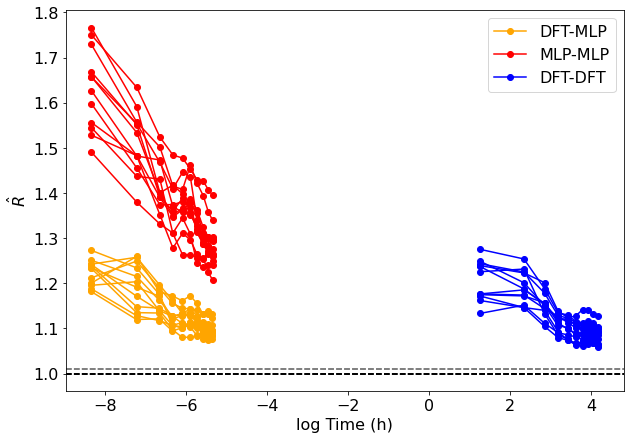

In [213]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7), sharey=True)

for key in rhat_s.keys():
    ax.plot(np.log(time_mcmc_window[key][::100]), rhat_s[key][0], '-o',  label=key, color=color_keys[key])
    ax.axhline(1, c='k', ls='--')
    ax.axhline(1.01, c='grey', ls='--')
    ax.set_xlabel('log Time (h)')
    ax.set_ylabel(r'$ \hat{R}$')

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))

    ax.legend(by_label.values(), by_label.keys())

### 4.e Acceptance ratio histogram windows

In [214]:
accs = {key: mcmcs[key]['accs'].detach() for key in mcmcs.keys()}

In [119]:
import random
def generate_random_color():
    # Generate random RGB values
    red = random.uniform(0, 1)
    green = random.uniform(0, 1)
    blue = random.uniform(0, 1)

    # Return the RGB values as a tuple
    return red, green, blue

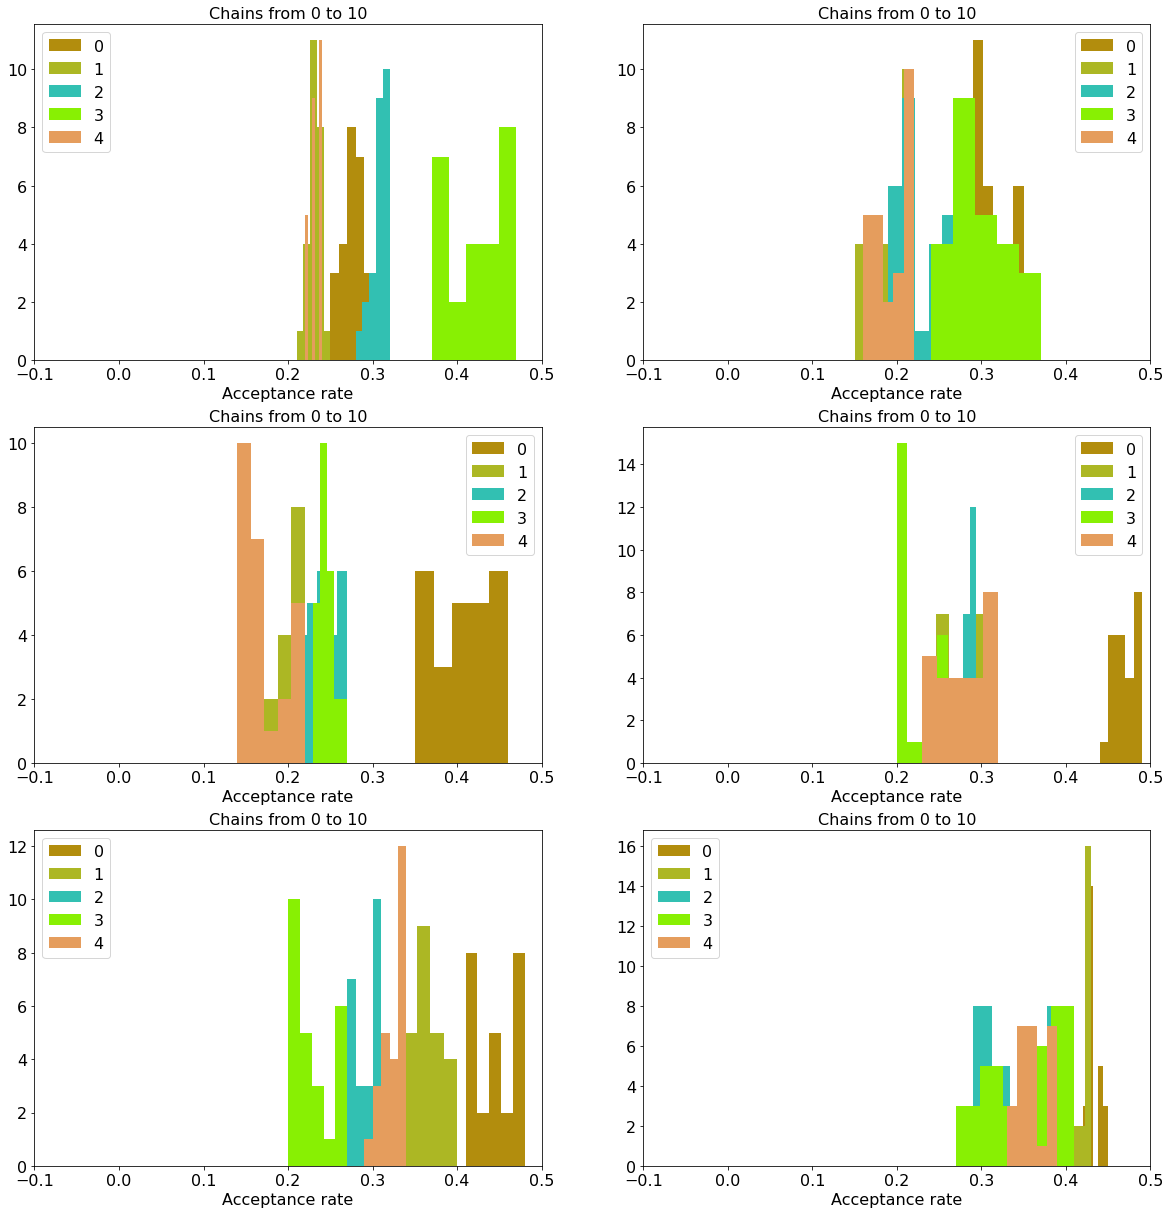

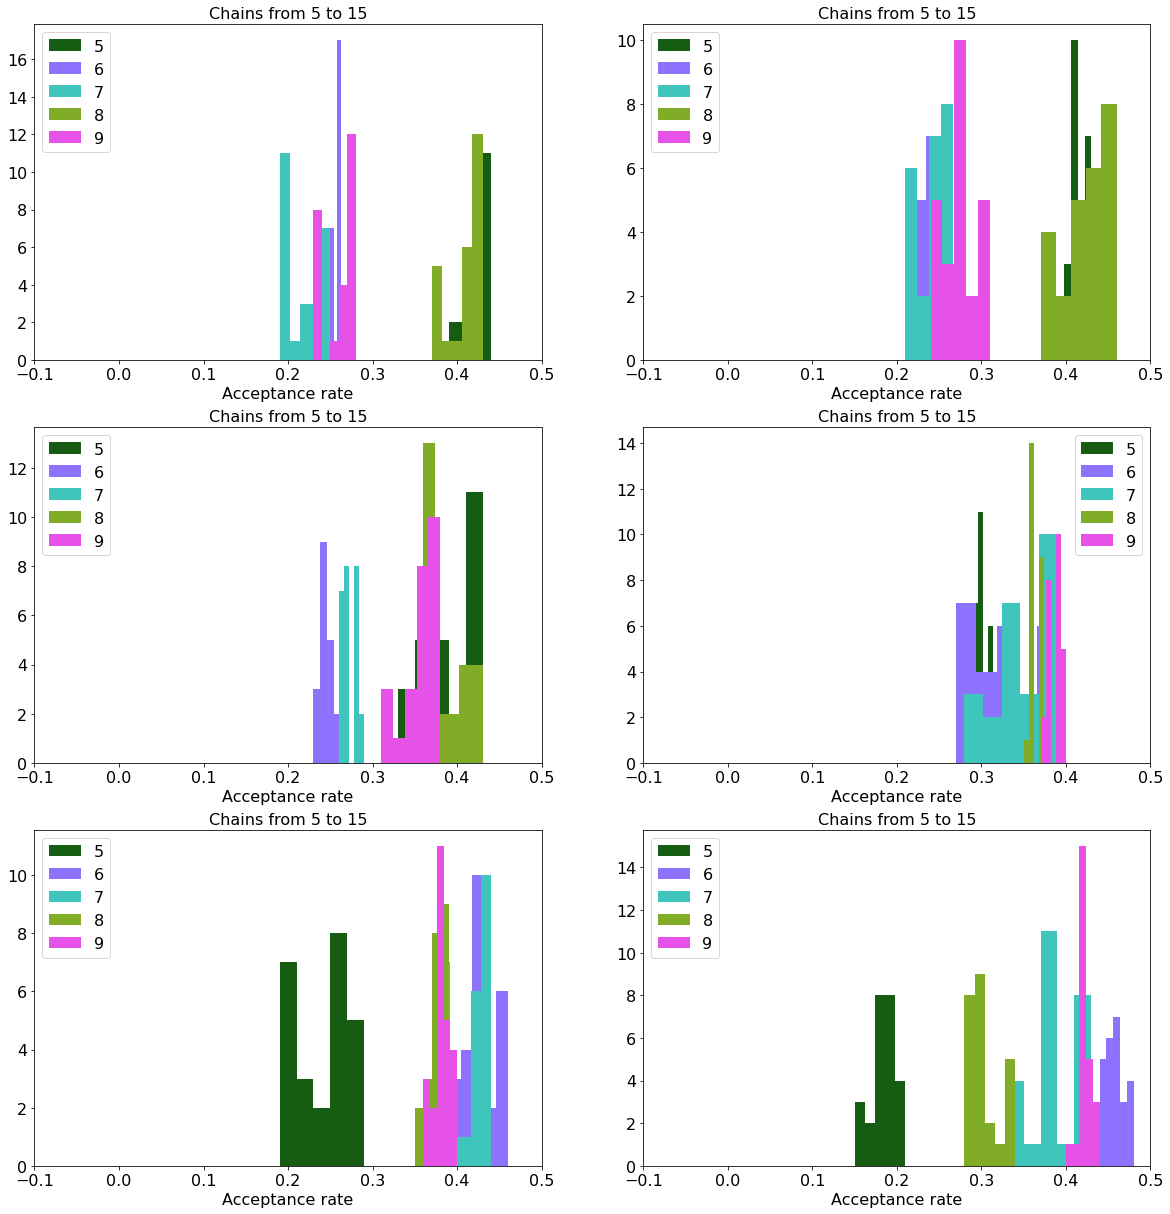

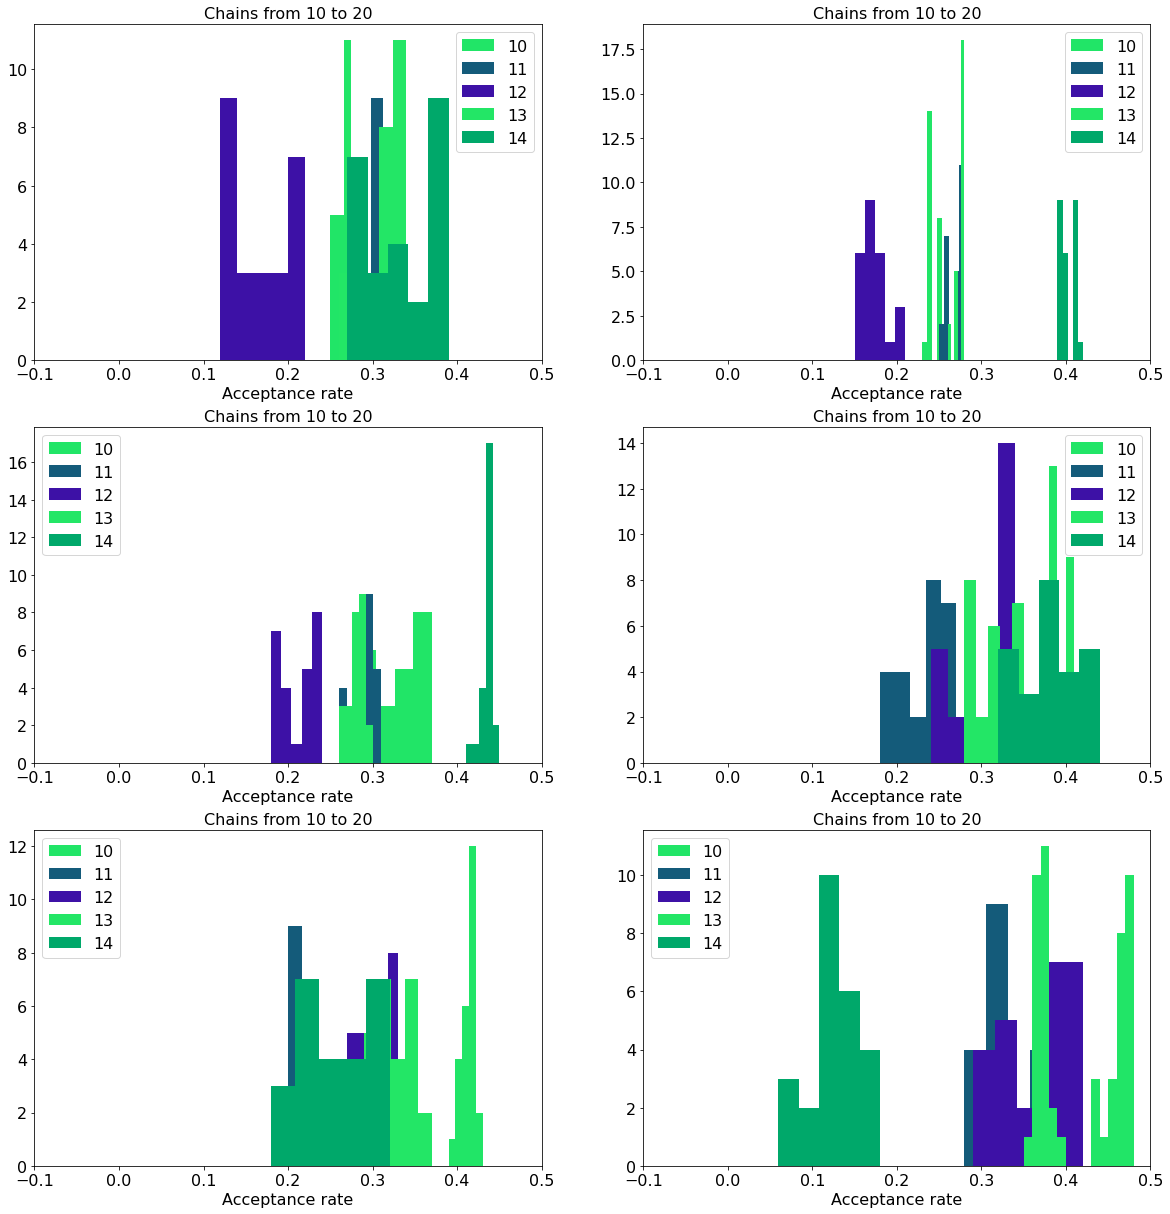

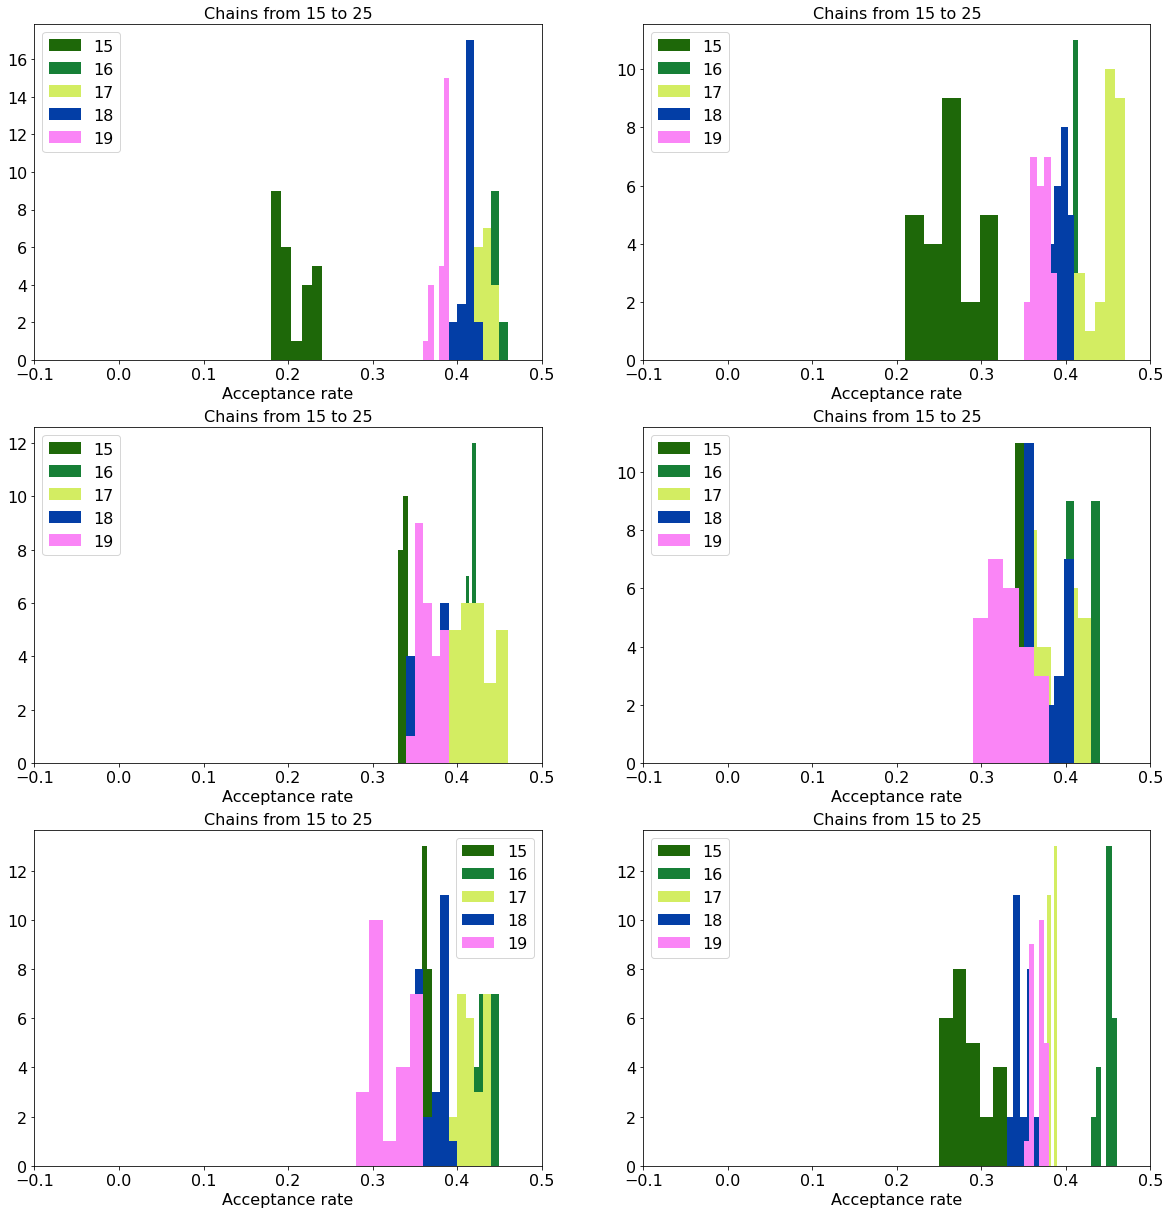

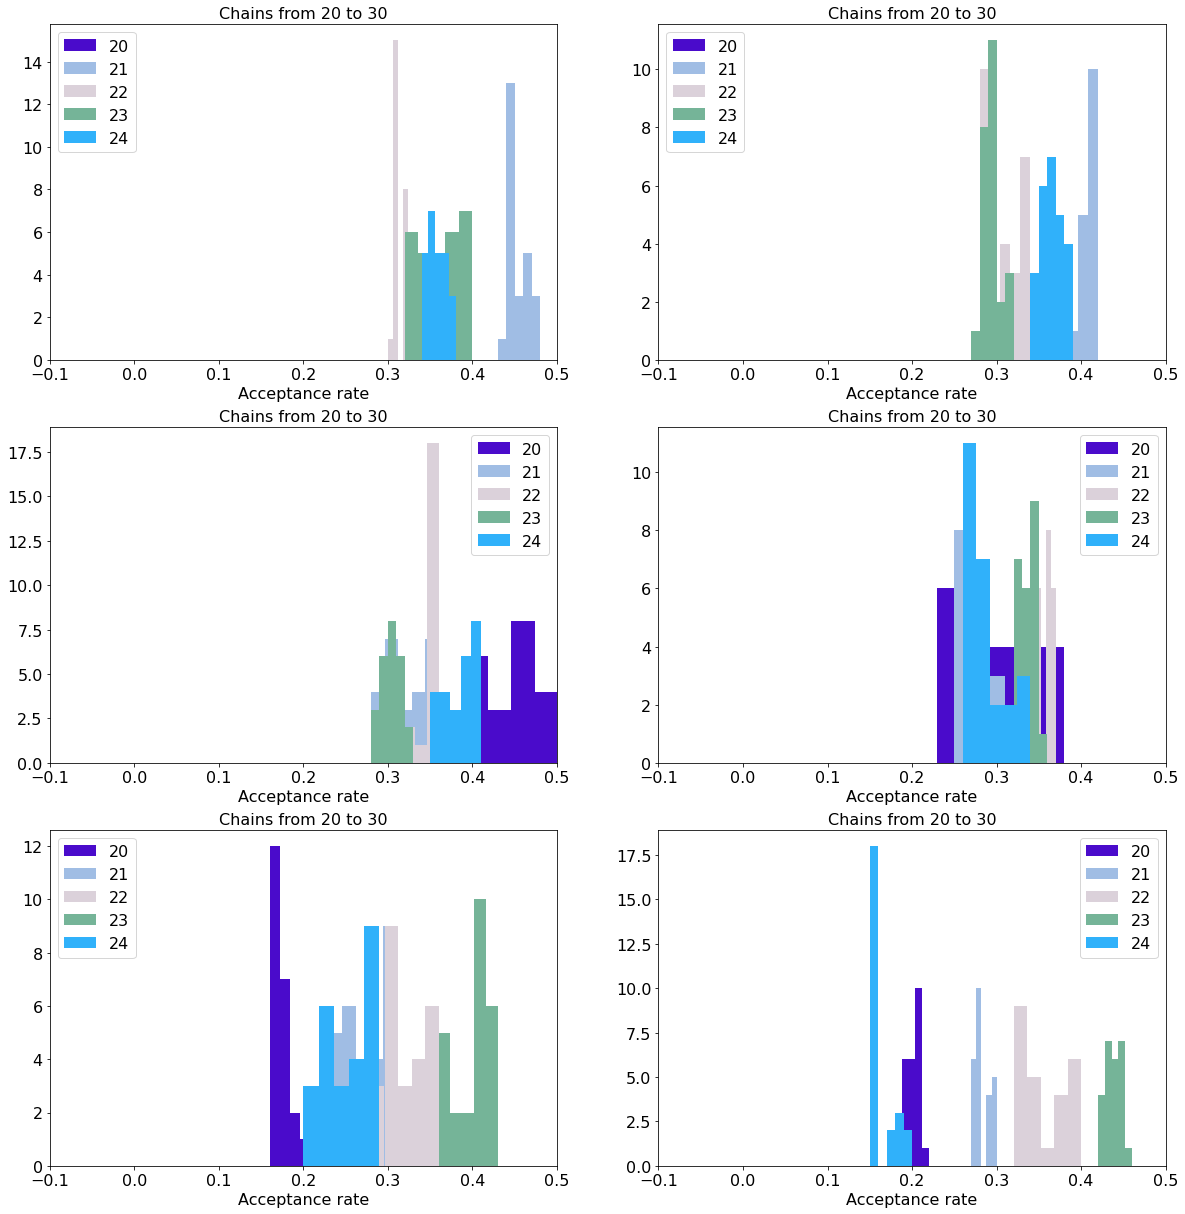

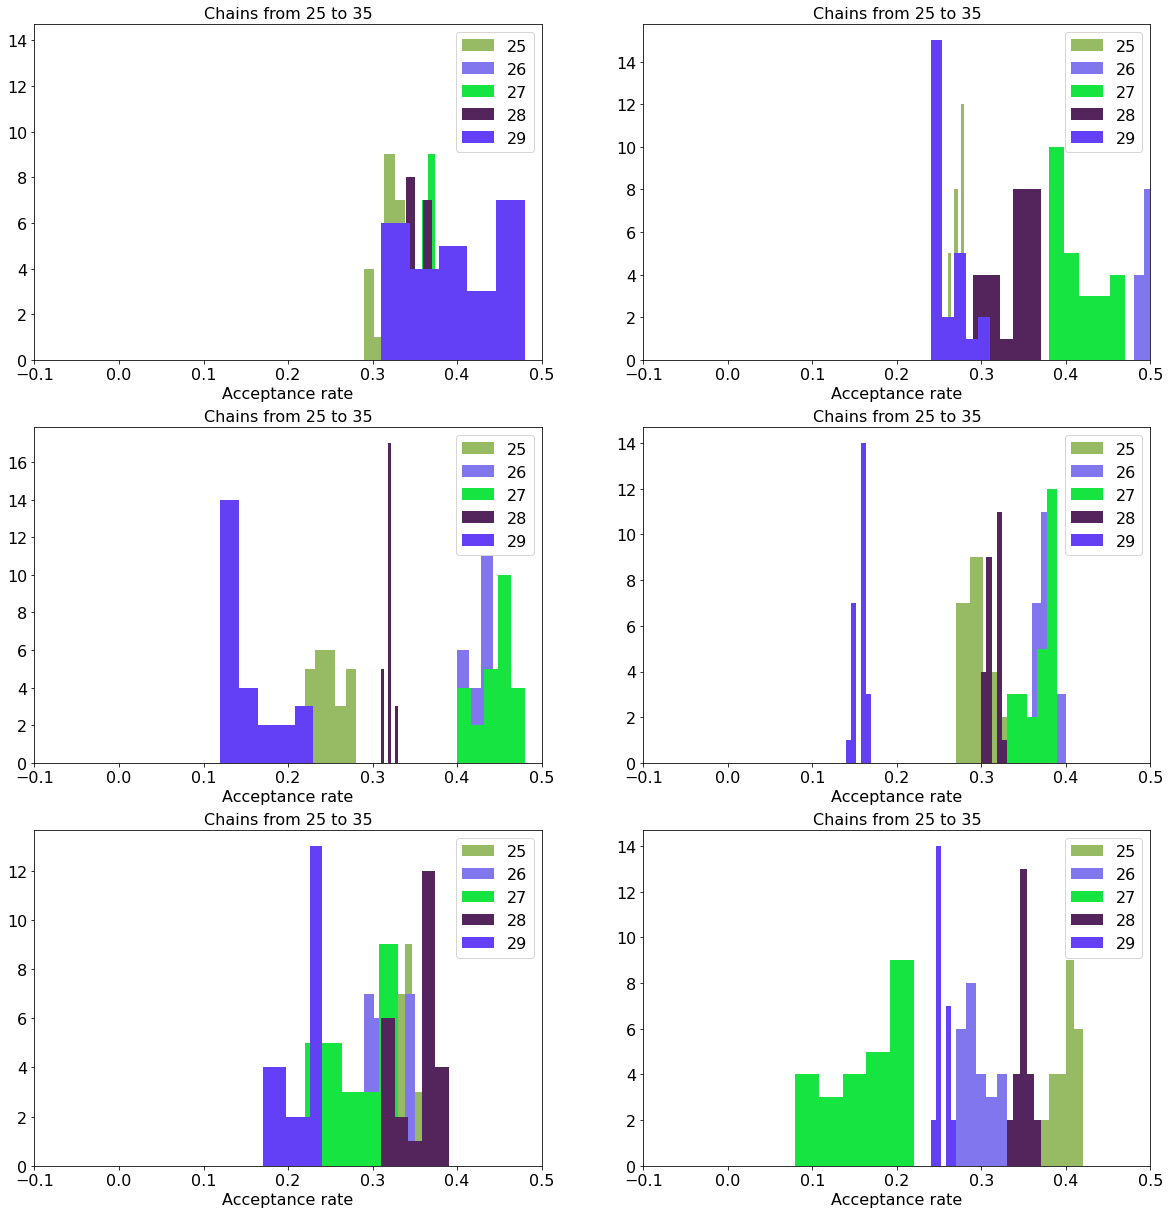

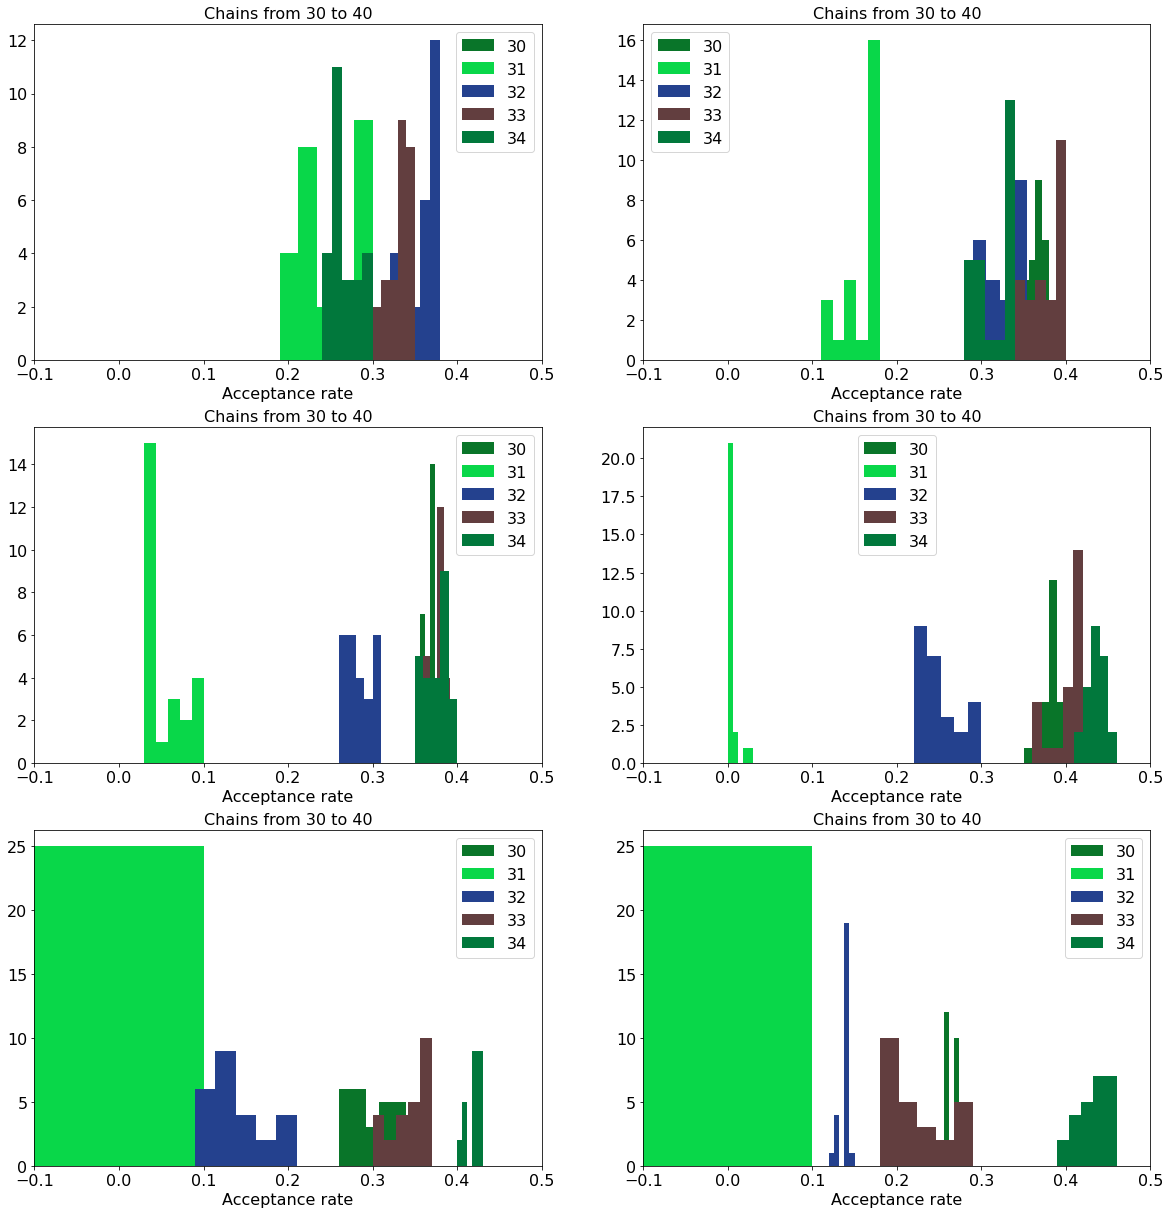

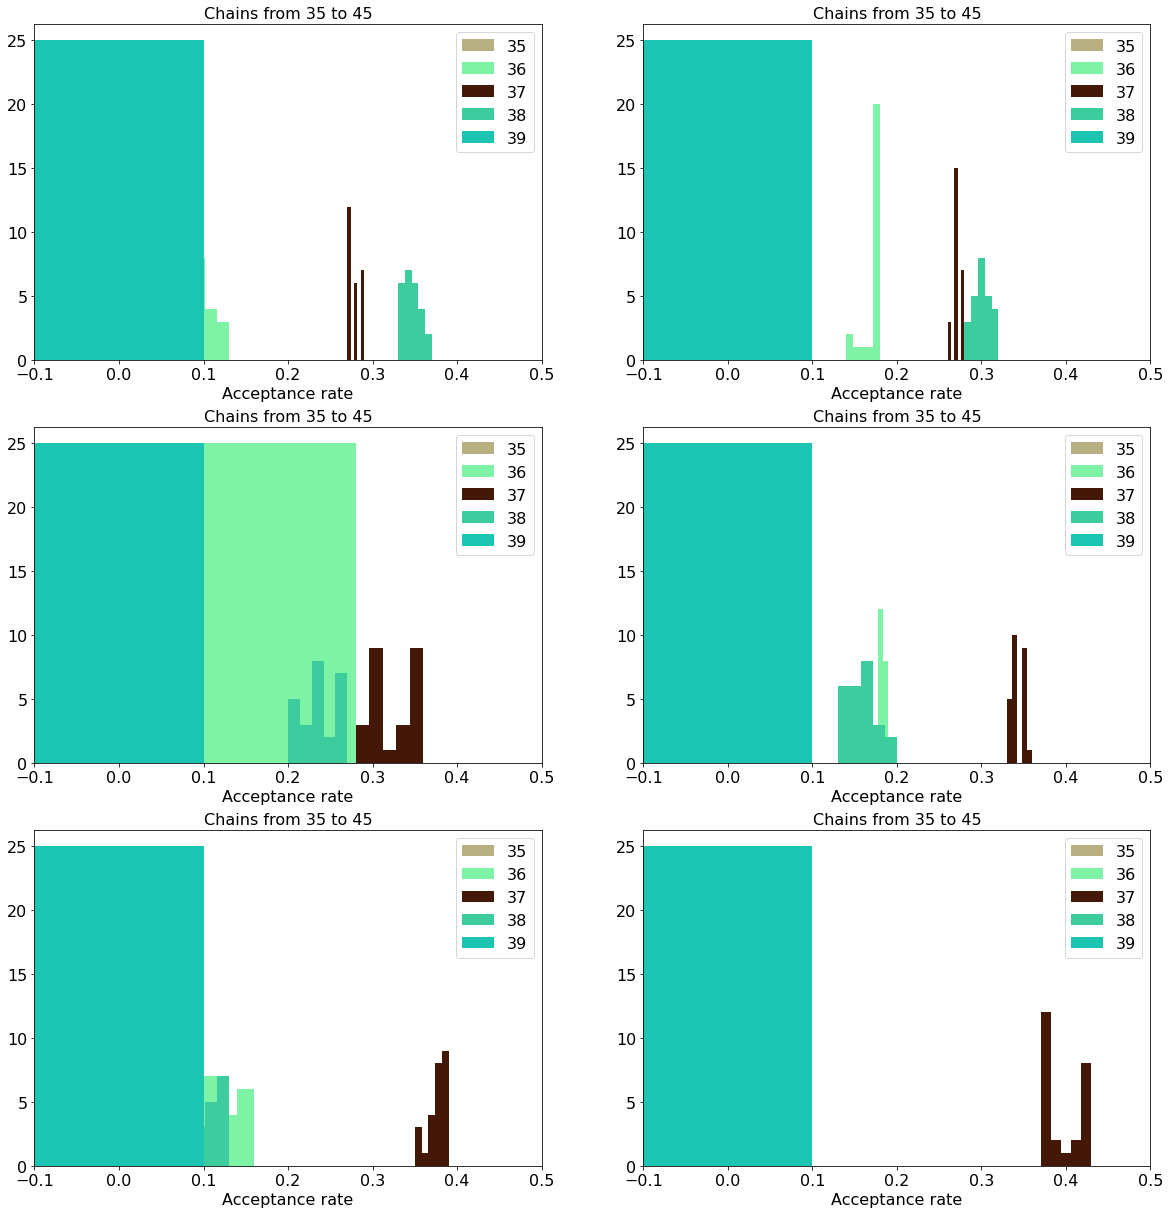

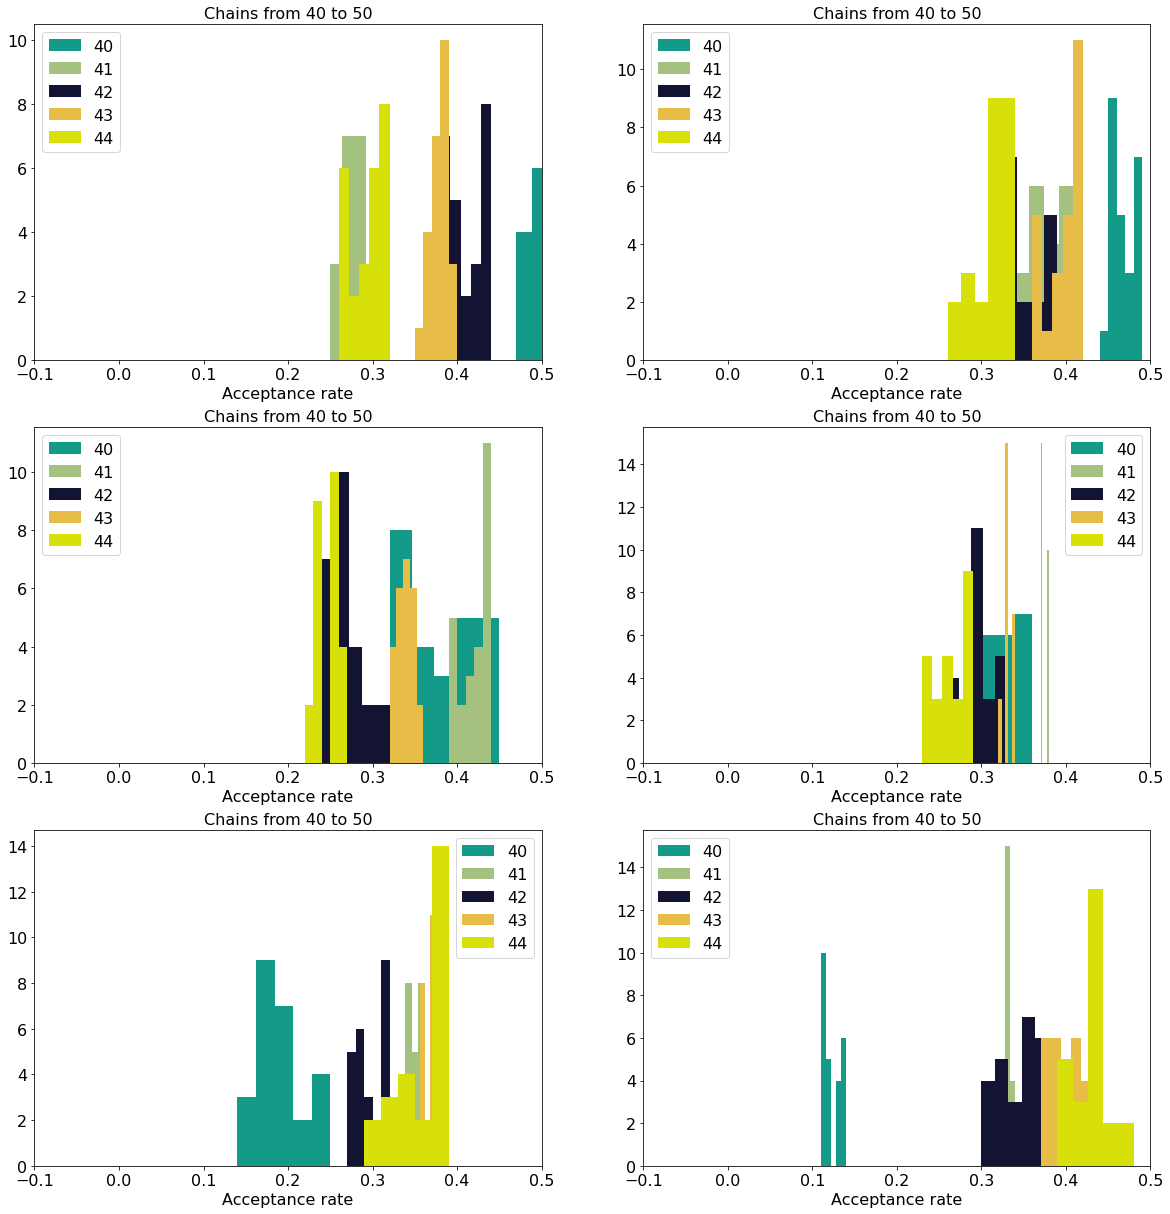

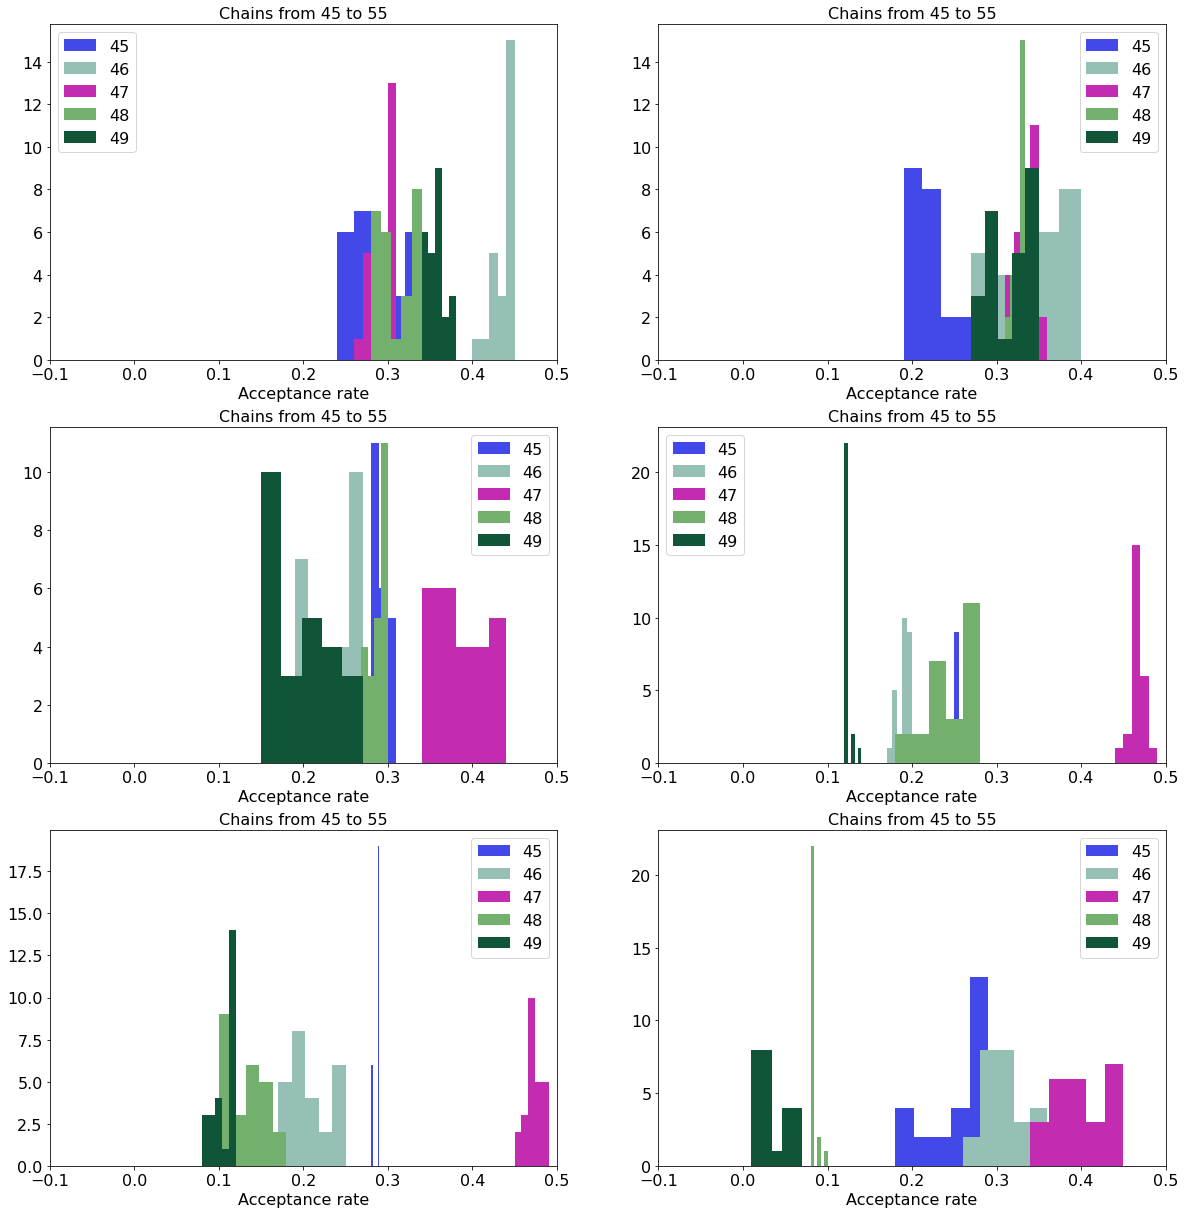

In [122]:
step = 5
for k in range(0, 50, step):
    fig, axs = plt.subplots(3, 2, figsize=(20, 21))
    axs = axs.ravel()
    i=0
    for j in range(k, k+step):
        color = generate_random_color()
        for acc, ax in zip(accs_slides_per_chain[j], axs):
            ax.hist(acc, label=j, color=color, bins=5, density=True)
            ax.legend()
            ax.set_title('Chains from {:d} to {:d}'.format(k, k+10))
            ax.set_xlabel('Acceptance rate')
            ax.set_xlim(-0.1, 0.5)

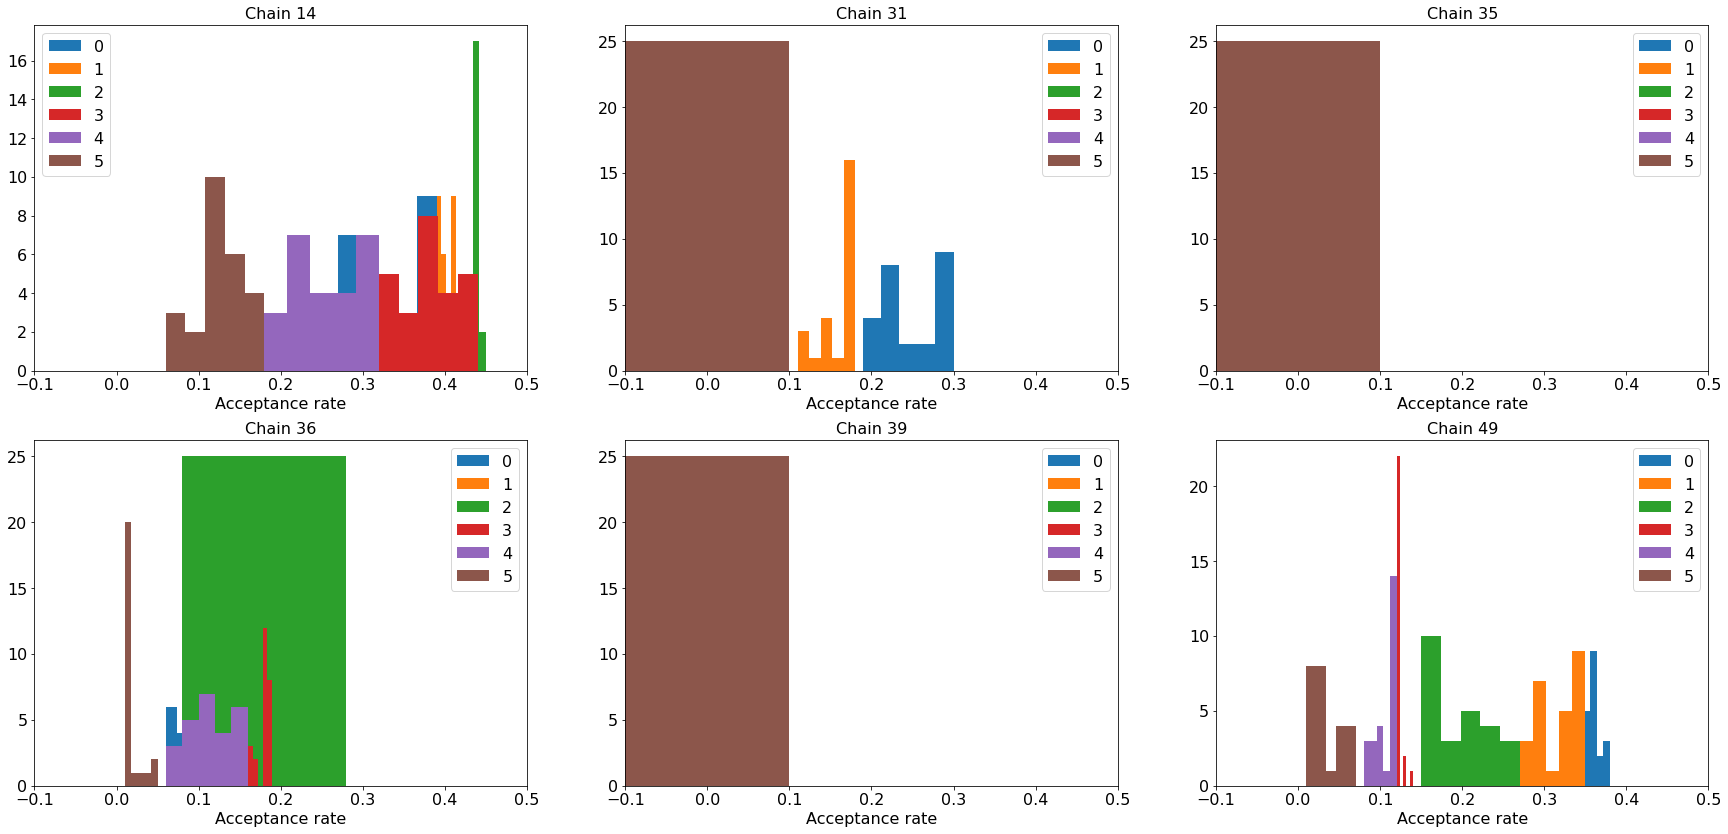

In [131]:
chains_low_accs=[14, 31, 35, 36, 39, 49]
fig, axs = plt.subplots(2, 3, figsize=(30, 14))
axs = axs.ravel()
for i, ax in zip(chains_low_accs, axs):
    for j, acc in enumerate(accs_slides_per_chain[i]):
        ax.hist(acc, label=j, bins=5)
        ax.legend()
        ax.set_title('Chain {:d}'.format(i))
        ax.set_xlabel('Acceptance rate')
        ax.set_xlim(-0.1, 0.5)

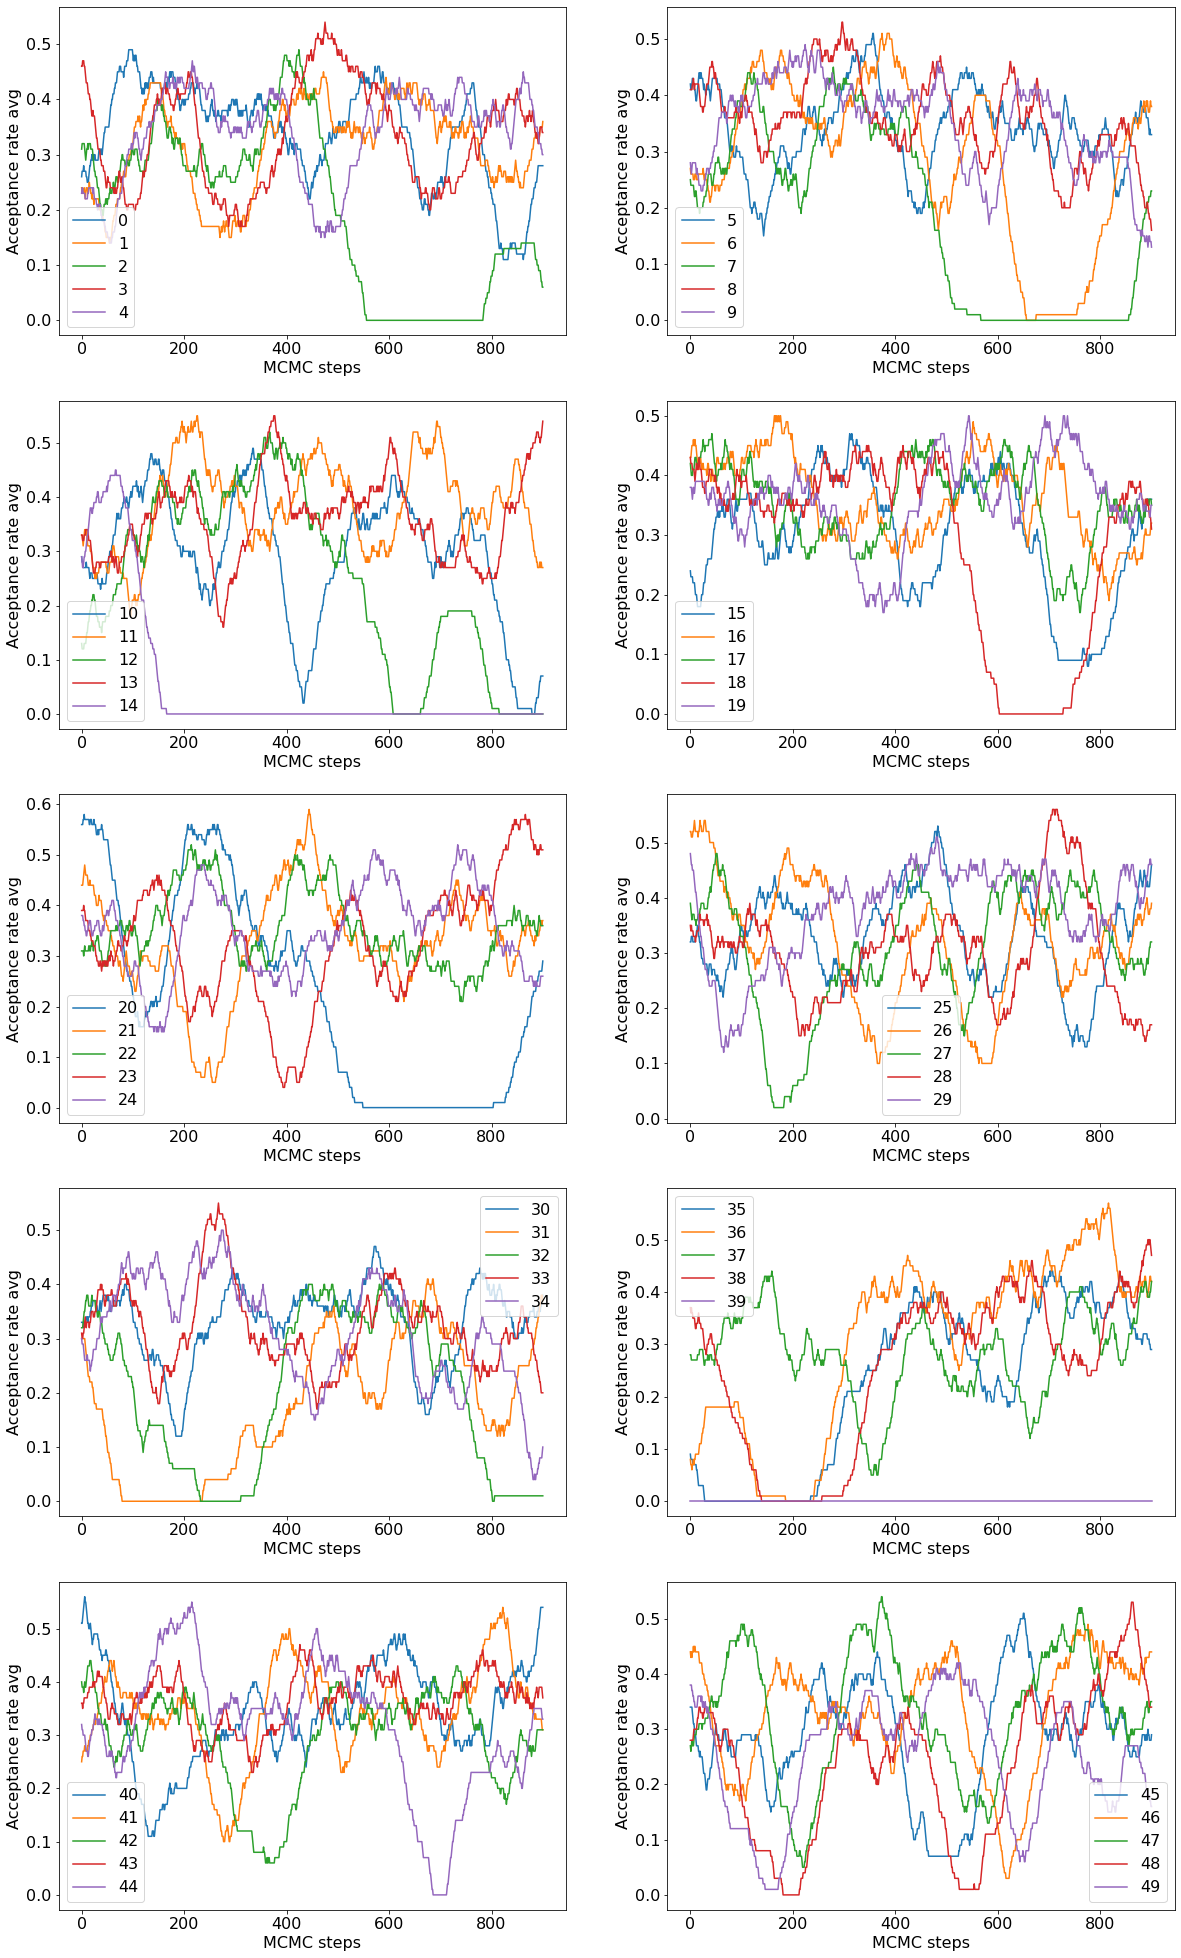

In [219]:
nchains=50
nrow=160
accs_slides_per_chain=[]
arrs_slides_per_chain = []
for chain in range(nchains):
    arr = sliding_window_view(accs['DFT-DFT'][:, chain], 100, axis=0).mean(axis=1)
    slides = []
    for i in range(6):
        slides.append(arr[i*nrows:(i+1)*nrows])
    accs_slides_per_chain.append(slides)
    arrs_slides_per_chain.append(arr)

fig, axs = plt.subplots(5, 2, figsize=(20, 35))
axs = axs.ravel()
for k, ax in zip(list(range(0, 50, 5)), axs):
    i=k
    for arr in arrs_slides_per_chain[k:k+5]:
        ax.plot(arr, label=i)
        ax.legend()
        ax.set_xlabel('MCMC steps')
        ax.set_ylabel('Acceptance rate avg')
        i=i+1